# SNC Enrichment Analysis

Reads `peak_selection/regions_all.parquet` (produced by `13a_peak_selection.ipynb`)
and runs SNC enrichment analysis for every cell type and module.

**Steps:**
1. Precompute SNC count per peak for the entire dataset (1-time, cached to parquet)
2. Run enrichment tests using contrast-specific backgrounds:
   - **Fisher's exact** (one-tailed): tests whether the fraction of foreground peaks
     with ≥1 SNC is higher than background (hypergeometric / presence–absence)
   - **Permutation** (10,000 draws, without replacement): tests whether the *mean
     n_snc per foreground peak* exceeds expectation from a random background draw —
     uses actual counts, not binary flags, so it is genuinely complementary to
     Fisher's and more sensitive for peaks carrying multiple SNCs
3. Apply BH FDR correction separately to both p-values
4. Generate plots:
   - **SNC count vs DESeq2 stats**: boxplots of LFC and sign(LFC)·−log10(padj)
     grouped by n_snc category (0 / 1 / 2 / 3+) within foreground peaks
   - **Enrichment dotplot**: fold enrichment × significance across all modules × cell types

**SNC source**: Prüfer et al. fixed modern-human-specific SNCs
(`modern_human_specific_and_fixed_0.9 == 1`), mapped to hg38.

**Background strategy**: contrast-specific — e.g. "Human UP vs All" is tested
against all peaks detected in all 6 species (matching the DESeq2 design).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.multitest import multipletests
import pybedtools

from src.evolutionary_heatmap import (
    build_snc_backgrounds,
    load_snc_bedtool,
    precompute_snc_counts,
    compute_snc_enrichment,
    plot_snc_enrichment_dotplot,
    plot_snc_vs_stats,
)

print("Imports OK")

Imports OK


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = "/cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks"
CONS_DIR   = f"{BASE}/cross_species_consensus_v3"
DESEQ_DIR  = f"{CONS_DIR}/13_deseq2_R_pseudobulk"
ANNO_PATH  = f"{CONS_DIR}/07_master_annotation/master_annotation_corrected.tsv"
BRANCH_DIR = f"{DESEQ_DIR}/differential_results/evolutionary_branches"
SNC_PATH   = ("/cluster/project/treutlein/USERS/jjans/analysis/adult_intestine"
               "/dl_models/data/SNC/Prufer_SNC_hg38_full.bed")

SPECIES = ["Human", "Bonobo", "Chimpanzee", "Gorilla", "Macaque", "Marmoset"]

# ── Input / output ─────────────────────────────────────────────────────────────
IN_REGIONS = Path(DESEQ_DIR) / "peak_selection" / "regions_all.parquet"
OUT_ENRICH = Path(DESEQ_DIR) / "enrichment" / "SNC"
SNC_CACHE  = OUT_ENRICH / "peak_snc_counts.parquet"

OUT_ENRICH.mkdir(parents=True, exist_ok=True)
print(f"Reading regions from : {IN_REGIONS}")
print(f"SNC cache            : {SNC_CACHE}")
print(f"Output               : {OUT_ENRICH}")

Reading regions from : /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/peak_selection/regions_all.parquet
SNC cache            : /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/peak_snc_counts.parquet
Output               : /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC


In [3]:
# ── Load regions_all ─────────────────────────────────────────────────────────
print("Loading regions_all...")
regions_all_df = pd.read_parquet(IN_REGIONS)
print(f"  {len(regions_all_df):,} peak-module entries")
print(f"  Cell types : {regions_all_df['cell_type'].nunique()}")
print(f"  Modules    : {regions_all_df['module'].nunique()}")

# ── Load master annotation ────────────────────────────────────────────────────
print("\nLoading master annotation...")
anno = pd.read_csv(ANNO_PATH, sep="\t", low_memory=False).set_index("peak_id")
det_cols = {sp: f"{sp}_det" for sp in SPECIES}
print(f"  {anno.shape[0]:,} peaks")

# ── Build contrast-specific SNC backgrounds ───────────────────────────────────
snc_backgrounds = build_snc_backgrounds(anno, det_cols, SPECIES)
print("\nSNC backgrounds (peaks detected in relevant species):")
for mod, bg in snc_backgrounds.items():
    print(f"  {mod:<35} {len(bg):>8,} peaks")

# ── Load fixed SNCs ───────────────────────────────────────────────────────────
print("\nLoading SNC BED file...")
snc_bt = load_snc_bedtool(SNC_PATH, filter_fixed=True)
print(f"  {len(snc_bt):,} fixed SNCs loaded")

Loading regions_all...
  87,397 peak-module entries
  Cell types : 13
  Modules    : 7

Loading master annotation...
  1,142,003 peaks

SNC backgrounds (peaks detected in relevant species):
  Human-specific DNA                   629,491 peaks
  Human UP vs All                       64,058 peaks
  ILS: Human + Gorilla UP              121,016 peaks
  ILS: Human + Chimp UP                121,016 peaks
  ILS: Human + Bonobo UP               121,016 peaks
  Great Apes UP vs Macaque              81,809 peaks
  Old World UP vs Marmoset              64,058 peaks

Loading SNC BED file...
  SNC file loaded: 321,719 rows
  SNCs after fixed filter (>=0.9): 136,518
  136,518 fixed SNCs loaded


In [4]:
# ── Precompute SNC count for every peak in the annotation ─────────────────────
# This pybedtools intersect is run once and cached.  All subsequent analyses
# use the parquet file — no pybedtools needed after this cell.

print("Precomputing SNC counts per peak (1-time operation, cached)...")
snc_counts_df = precompute_snc_counts(anno, snc_bt, SNC_CACHE)

print(f"\nn_snc distribution:")
print(snc_counts_df["n_snc"].describe().round(3))
pct_any = 100 * (snc_counts_df["n_snc"] >= 1).mean()
print(f"\nPeaks with ≥1 SNC: {(snc_counts_df['n_snc'] >= 1).sum():,}  ({pct_any:.1f}%)")

Precomputing SNC counts per peak (1-time operation, cached)...
  Loading cached SNC counts from /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/peak_snc_counts.parquet

n_snc distribution:
count    1039336.000
mean           0.025
std            0.179
min            0.000
25%            0.000
50%            0.000
75%            0.000
max            7.000
Name: n_snc, dtype: float64

Peaks with ≥1 SNC: 23,192  (2.2%)


In [5]:
# ── SNC enrichment (fast: uses precomputed counts) ────────────────────────────

all_enrichment_rows = []
cell_types = regions_all_df["cell_type"].unique().tolist()

for cell_type in cell_types:
    print(f"  {cell_type}")
    ct_df = regions_all_df[regions_all_df["cell_type"] == cell_type]
    regions_all = dict(ct_df.groupby("module", sort=False)["peak_id"].apply(list))

    rows = compute_snc_enrichment(
        cell_type=cell_type,
        regions_all=regions_all,
        module_backgrounds=snc_backgrounds,
        snc_counts_df=snc_counts_df,
        n_permutations=10_000,
    )
    all_enrichment_rows.extend(rows)

    for r in rows:
        fe_str = f"{r['fold_enrichment']:.2f}x" if not pd.isna(r['fold_enrichment']) else "n/a"
        fp_str = f"{r['fisher_pvalue']:.2e}"    if not pd.isna(r['fisher_pvalue'])    else "n/a"
        pp_str = f"{r['perm_pvalue']:.4f}"      if not pd.isna(r['perm_pvalue'])      else "n/a"
        d_str  = f"{r['density_fg_snc_per_kb']:.3f}" if not pd.isna(r['density_fg_snc_per_kb']) else "n/a"
        print(f"    {r['module']:<35} FE={fe_str:>7}  "
              f"fisher_p={fp_str}  perm_p={pp_str}  density={d_str}/kb")

print(f"\nDone. {len(cell_types)} cell types processed.")

  Colonocytes
    Human-specific DNA                  FE=  0.47x  fisher_p=1.00e+00  perm_p=1.0000  density=0.023/kb
    Human UP vs All                     FE=  1.54x  fisher_p=1.07e-01  perm_p=0.0320  density=0.102/kb
    ILS: Human + Gorilla UP             FE=  1.46x  fisher_p=4.00e-01  perm_p=0.0918  density=0.140/kb
    ILS: Human + Chimp UP               FE=  5.54x  fisher_p=4.95e-02  perm_p=0.0794  density=0.267/kb
    ILS: Human + Bonobo UP              FE=  0.68x  fisher_p=7.74e-01  perm_p=0.7773  density=0.033/kb
    Great Apes UP vs Macaque            FE=  0.90x  fisher_p=6.76e-01  perm_p=0.7713  density=0.043/kb
    Old World UP vs Marmoset            FE=  1.04x  fisher_p=4.29e-01  perm_p=0.4933  density=0.056/kb
  Crypt Fibroblasts WNT2B+
    Human-specific DNA                  FE=  0.47x  fisher_p=1.00e+00  perm_p=1.0000  density=0.023/kb
    Human UP vs All                     FE=  1.82x  fisher_p=2.45e-02  perm_p=0.0015  density=0.132/kb
    ILS: Human + Gorilla UP     

In [6]:
# ── FDR correction and save ───────────────────────────────────────────────────

enrich_df = pd.DataFrame(all_enrichment_rows)

def _apply_fdr(df, pval_col, padj_col):
    padj = np.full(len(df), np.nan)
    valid = df[pval_col].notna()
    if valid.sum() > 0:
        _, padj_vals, _, _ = multipletests(df.loc[valid, pval_col], method="fdr_bh")
        padj[valid.values] = padj_vals
    df[padj_col] = padj

_apply_fdr(enrich_df, "fisher_pvalue", "fisher_padj")
_apply_fdr(enrich_df, "perm_pvalue",   "perm_padj")

tsv_path = OUT_ENRICH / "SNC_enrichment_all_celltypes.tsv"
enrich_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Enrichment table ({len(enrich_df)} rows) saved → {tsv_path}")

# Show top hits (Fisher padj) including mean SNC counts per peak
sig = enrich_df[enrich_df["fisher_padj"] < 0.05].sort_values("fold_enrichment",
                                                               ascending=False)
print(f"\nSignificant enrichments (fisher_padj < 0.05): {len(sig)}")
display(sig[["cell_type", "module", "n_fg", "n_fg_snc", "pct_fg_snc",
             "pct_bg_snc", "fold_enrichment",
             "mean_snc_fg", "mean_snc_bg",
             "density_fg_snc_per_kb", "density_bg_snc_per_kb",
             "fisher_pvalue", "fisher_padj",
             "perm_pvalue", "perm_padj"]].head(20))

# Also show top-20 by fold enrichment regardless of significance
print("\nTop 20 by fold enrichment (uncorrected):")
display(enrich_df.dropna(subset=["fold_enrichment"])
        .sort_values("fold_enrichment", ascending=False)
        [["cell_type", "module", "n_fg", "fold_enrichment",
          "mean_snc_fg", "mean_snc_bg",
          "fisher_pvalue", "fisher_padj", "perm_pvalue", "perm_padj"]].head(20))

Enrichment table (91 rows) saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/SNC_enrichment_all_celltypes.tsv

Significant enrichments (fisher_padj < 0.05): 0


,cell_type,module,n_fg,n_fg_snc,pct_fg_snc,pct_bg_snc,fold_enrichment,mean_snc_fg,mean_snc_bg,density_fg_snc_per_kb,density_bg_snc_per_kb,fisher_pvalue,fisher_padj,perm_pvalue,perm_padj



Top 20 by fold enrichment (uncorrected):


,cell_type,module,n_fg,fold_enrichment,mean_snc_fg,mean_snc_bg,fisher_pvalue,fisher_padj,perm_pvalue,perm_padj
17,ECs,ILS: Human + Chimp UP,3,13.847,0.3333,0.0273,0.070513,1.0,0.0663,1.000000
81,T cells,ILS: Human + Bonobo UP,7,5.934,0.1429,0.0273,0.156861,1.0,0.1550,1.000000
3,Colonocytes,ILS: Human + Chimp UP,15,5.540,0.1333,0.0273,0.049450,1.0,0.0794,1.000000
65,Specialized Fibroblasts SYNM+,ILS: Human + Gorilla UP,37,3.370,0.0811,0.0273,0.059126,1.0,0.0957,1.000000
79,T cells,ILS: Human + Gorilla UP,48,2.597,0.0625,0.0273,0.108849,1.0,0.1609,1.000000
57,Specialized Fibroblasts RSPO3+ only,Human UP vs All,113,2.195,0.0973,0.0275,0.057495,1.0,0.0015,0.066750
15,ECs,Human UP vs All,19,2.172,0.0526,0.0275,0.372726,1.0,0.3715,1.000000
52,Plasma B cells,ILS: Human + Chimp UP,21,1.978,0.0476,0.0273,0.400644,1.0,0.4012,1.000000
8,Crypt Fibroblasts WNT2B+,Human UP vs All,318,1.823,0.0660,0.0275,0.024457,1.0,0.0015,0.066750
58,Specialized Fibroblasts RSPO3+ only,ILS: Human + Gorilla UP,23,1.806,0.0870,0.0273,0.429166,1.0,0.1413,1.000000


In [7]:
# ── SNC vs DESeq2 stats plots ─────────────────────────────────────────────────
# Per-cell-type: for each module, boxplots of LFC and sign(LFC)·−log10(padj)
#                grouped by n_snc category (0 / 1 / 2 / 3+)
# Per-module   : for each cell type, boxplot of LFC grouped by n_snc category
#
# Shows whether SNC burden within foreground peaks predicts differential
# accessibility strength.

print("Generating SNC vs DESeq2 stats plots...")
plot_snc_vs_stats(
    regions_all_df=regions_all_df,
    snc_counts_df=snc_counts_df,
    module_backgrounds=snc_backgrounds,
    branch_dir=BRANCH_DIR,
    out_dir=OUT_ENRICH,
)
print("Done.")

Generating SNC vs DESeq2 stats plots...
  Per-cell-type → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/snc_vs_stats_by_celltype/Colonocytes_snc_vs_stats.pdf
  Per-cell-type → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/snc_vs_stats_by_celltype/Crypt_Fibroblasts_WNT2B+_snc_vs_stats.pdf
  Per-cell-type → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/snc_vs_stats_by_celltype/ECs_snc_vs_stats.pdf
  Per-cell-type → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/snc_vs_stats_by_celltype/Enterocytes_snc_vs_stats.pdf
  Per-cell-type → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_

In [8]:
# ── Enrichment dotplot ────────────────────────────────────────────────────────

dot_path = OUT_ENRICH / "SNC_enrichment_dotplot.pdf"
plot_snc_enrichment_dotplot(
    enrich_df=enrich_df,
    out_path=dot_path,
    padj_col="fisher_padj",
    fe_col="fold_enrichment",
    pval_threshold=0.05,
)
print(f"Dotplot saved → {dot_path}")

  Dotplot saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/SNC_enrichment_dotplot.pdf
Dotplot saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/SNC_enrichment_dotplot.pdf


---
## Subtype-pooled SNC enrichment with peak window sweep

Pool foreground peaks across cell types within each biological subtype (Epithelial, Mesenchymal, Endothelial, Immune) to increase statistical power, and test multiple peak-flank distances to capture SNCs that flank rather than overlap ATAC peaks.

**Note:** the optimal-flank fold enrichment values are exploratory (d is selected post-hoc). The enrichment-vs-distance curves are the primary evidence.

In [9]:
# ── Cell A: Subtype map, flank values, and pooled FG sets ─────────────────────

SUBTYPES = {
    "Epithelial":  ["Colonocytes", "Enterocytes", "Goblet cells", "Stem cells", "TA cells"],
    "Mesenchymal": ["Crypt Fibroblasts WNT2B+",
                    "Specialized Fibroblasts RSPO3+ only",
                    "Specialized Fibroblasts SYNM+"],
    "Endothelial": ["ECs"],
    "Immune":      ["Macrophages", "Naive B cells", "Plasma B cells", "T cells"],
}
FLANK_VALUES = [0, 100, 250, 500, 1000, 2000]  # bp added to each side of each peak

# Pool FG peaks per subtype: union across constituent cell types, per module
subtype_regions = {}
for subtype, members in SUBTYPES.items():
    subtype_regions[subtype] = {}
    for module in snc_backgrounds.keys():
        peaks = set()
        for ct in members:
            mask = (regions_all_df["cell_type"] == ct) & (regions_all_df["module"] == module)
            peaks |= set(regions_all_df.loc[mask, "peak_id"])
        subtype_regions[subtype][module] = list(peaks)

# Report pooled set sizes
print("Pooled foreground peak counts per subtype/module:")
for subtype, modules in subtype_regions.items():
    print(f"\n  {subtype}:")
    for module, peaks in modules.items():
        print(f"    {module:<35s} n={len(peaks):,}")

Pooled foreground peak counts per subtype/module:

  Epithelial:
    Human-specific DNA                  n=1,594
    Human UP vs All                     n=12,231
    ILS: Human + Gorilla UP             n=1,937
    ILS: Human + Chimp UP               n=534
    ILS: Human + Bonobo UP              n=1,053
    Great Apes UP vs Macaque            n=2,961
    Old World UP vs Marmoset            n=9,968

  Mesenchymal:
    Human-specific DNA                  n=1,594
    Human UP vs All                     n=4,964
    ILS: Human + Gorilla UP             n=885
    ILS: Human + Chimp UP               n=531
    ILS: Human + Bonobo UP              n=332
    Great Apes UP vs Macaque            n=164
    Old World UP vs Marmoset            n=1,264

  Endothelial:
    Human-specific DNA                  n=1,594
    Human UP vs All                     n=181
    ILS: Human + Gorilla UP             n=84
    ILS: Human + Chimp UP               n=7
    ILS: Human + Bonobo UP              n=14
    Great Ap

In [10]:
# ── Cell B: Precompute / load SNC counts for each flank distance ──────────────
# flank=0 reuses the already-loaded snc_counts_df; others are cached separately.

snc_counts_by_flank = {}
for d in FLANK_VALUES:
    if d == 0:
        snc_counts_by_flank[d] = snc_counts_df  # already loaded above
    else:
        cache = OUT_ENRICH / f"peak_snc_counts_flank{d}.parquet"
        snc_counts_by_flank[d] = precompute_snc_counts(anno, snc_bt, cache, flank_bp=d)

# SNC coverage diagnostic
print("\nSNC coverage across flank distances (all peaks in annotation):")
for d, df in snc_counts_by_flank.items():
    frac = (df["n_snc"] > 0).mean()
    mean_n = df["n_snc"].mean()
    print(f"  flank={d:5d} bp:  {frac:.1%} of peaks have ≥1 SNC  (mean {mean_n:.3f} SNCs/peak)")

  Building BedTool from 1,039,336 peaks (flank ±100 bp)...
  Intersecting with 136,518 SNCs (c=True)...
  SNC counts (1,039,336 peaks) saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/peak_snc_counts_flank100.parquet
  Building BedTool from 1,039,336 peaks (flank ±250 bp)...
  Intersecting with 136,518 SNCs (c=True)...
  SNC counts (1,039,336 peaks) saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/peak_snc_counts_flank250.parquet
  Building BedTool from 1,039,336 peaks (flank ±500 bp)...
  Intersecting with 136,518 SNCs (c=True)...
  SNC counts (1,039,336 peaks) saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/peak_snc_counts_flank500.parquet
  Building BedTool from 1,039,336 peaks (flank ±1000 bp)...
  Inter

In [12]:

sweep_rows = []
for d in FLANK_VALUES:
    peak_width = 500 + 2 * d  # effective window width for SNC density calc
    for subtype in SUBTYPES:
        rows = compute_snc_enrichment(
            cell_type=subtype,
            regions_all=subtype_regions[subtype],
            module_backgrounds=snc_backgrounds,
            snc_counts_df=snc_counts_by_flank[d],
            n_permutations=10_000,
            peak_width_bp=peak_width,
        )
        for r in rows:
            r["flank_bp"] = d
        sweep_rows.extend(rows)

sweep_df = pd.DataFrame(sweep_rows)

# FDR correction within each flank value (7 modules × 4 subtypes = 28 tests per d).
# _apply_fdr modifies a df in-place by adding a new column, so we work on a copy
# per group and write the adjusted p-values back to sweep_df explicitly.
sweep_df["fisher_padj"] = np.nan
sweep_df["perm_padj"]   = np.nan
for d, idx in sweep_df.groupby("flank_bp").groups.items():
    sub = sweep_df.loc[idx].copy()
    _apply_fdr(sub, "fisher_pvalue", "fisher_padj")
    _apply_fdr(sub, "perm_pvalue",   "perm_padj")
    sweep_df.loc[idx, "fisher_padj"] = sub["fisher_padj"].values
    sweep_df.loc[idx, "perm_padj"]   = sub["perm_padj"].values

sweep_df.to_csv(OUT_ENRICH / "SNC_enrichment_subtype_sweep.csv", index=False)
print(f"Sweep complete: {len(sweep_df)} rows ({len(FLANK_VALUES)} flanks × "
      f"{len(SUBTYPES)} subtypes × {len(snc_backgrounds)} modules)")
print(f"Significant (perm_padj < 0.05): {(sweep_df['perm_padj'] < 0.05).sum()}")
print(f"Significant (perm_padj < 0.10): {(sweep_df['perm_padj'] < 0.10).sum()}")
print()
display(sweep_df[sweep_df["perm_padj"] < 0.15]
        .sort_values("perm_padj")
        [["cell_type", "module", "flank_bp", "n_fg", "fold_enrichment",
          "perm_pvalue", "perm_padj"]])


Sweep complete: 168 rows (6 flanks × 4 subtypes × 7 modules)
Significant (perm_padj < 0.05): 0
Significant (perm_padj < 0.10): 1



,cell_type,module,flank_bp,n_fg,fold_enrichment,perm_pvalue,perm_padj
8,Mesenchymal,Human UP vs All,0,503,1.482,0.0037,0.0962


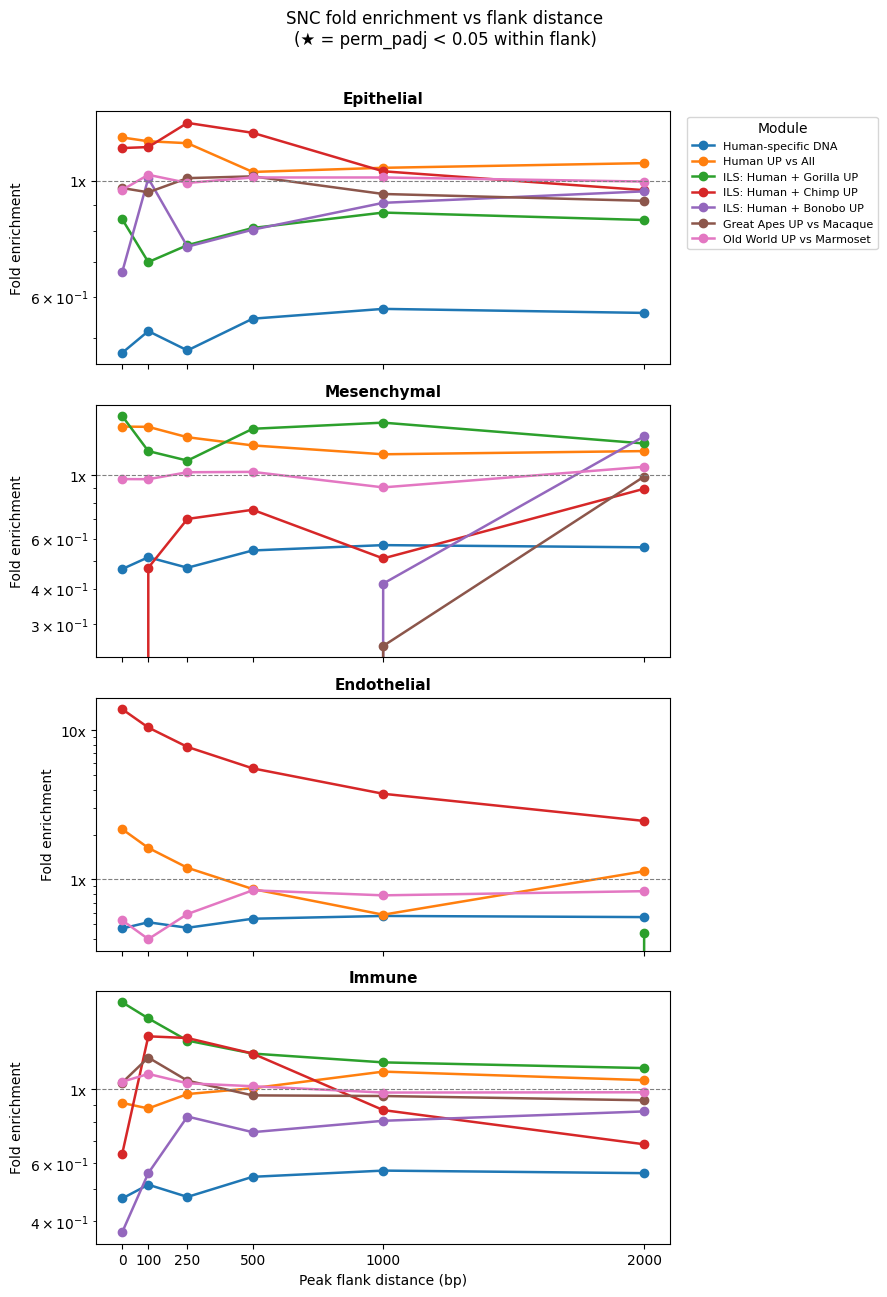

In [13]:
# ── Cell D: Enrichment vs flank distance curves ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

modules_ordered = list(snc_backgrounds.keys())
subtypes_ordered = list(SUBTYPES.keys())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(
    len(subtypes_ordered), 1,
    figsize=(9, 3.2 * len(subtypes_ordered)),
    sharex=True,
)

for ax, subtype in zip(axes, subtypes_ordered):
    for i, module in enumerate(modules_ordered):
        sub = (sweep_df[(sweep_df["cell_type"] == subtype) &
                        (sweep_df["module"] == module)]
               .sort_values("flank_bp"))
        if sub["fold_enrichment"].isna().all():
            continue
        fe    = sub["fold_enrichment"].values
        flank = sub["flank_bp"].values
        ax.plot(flank, fe, marker="o", label=module, color=colors[i % 10], lw=1.8)
        # Star markers where perm_padj < 0.05
        sig = (sub["perm_padj"] < 0.05).values
        if sig.any():
            ax.scatter(flank[sig], fe[sig], marker="*", s=150,
                       color=colors[i % 10], zorder=5)

    ax.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax.set_title(subtype, fontweight="bold", fontsize=11)
    ax.set_ylabel("Fold enrichment")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:.2g}x"))

axes[-1].set_xlabel("Peak flank distance (bp)")
axes[-1].set_xticks(FLANK_VALUES)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
               title="Module")
fig.suptitle("SNC fold enrichment vs flank distance\n(★ = perm_padj < 0.05 within flank)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_ENRICH / "SNC_enrichment_flank_sweep.pdf", bbox_inches="tight")
plt.show()

Best-flank result per subtype/module (d selected post-hoc — exploratory):


,cell_type,module,flank_bp,n_fg,fold_enrichment,perm_pvalue,perm_padj
0,Mesenchymal,Human UP vs All,0,503,1.482,0.0037,0.096200
1,Epithelial,Human UP vs All,250,1199,1.179,0.0320,0.416000
2,Mesenchymal,ILS: Human + Gorilla UP,1000,103,1.530,0.0326,0.423800
3,Immune,ILS: Human + Gorilla UP,2000,364,1.159,0.0562,0.720200
4,Endothelial,ILS: Human + Chimp UP,0,3,13.847,0.0663,0.431600
5,Immune,Great Apes UP vs Macaque,100,1080,1.247,0.0766,0.461240
6,Epithelial,ILS: Human + Chimp UP,1000,108,1.042,0.0805,0.616200
7,Immune,ILS: Human + Chimp UP,500,65,1.282,0.1852,0.802533
8,Mesenchymal,Old World UP vs Marmoset,2000,510,1.071,0.2175,0.948567
9,Immune,Human UP vs All,1000,634,1.131,0.3227,1.000000



Dot plot at best overall flank distance: 2000 bp
  Dotplot saved → /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/enrichment/SNC/SNC_enrichment_subtype_dotplot_flank2000.pdf


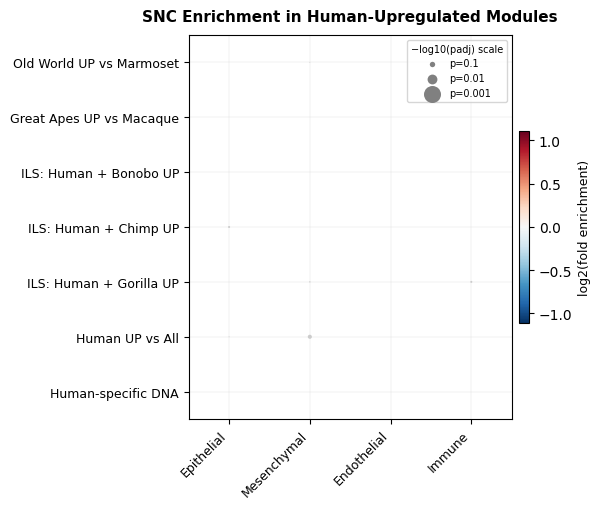

In [14]:
# ── Cell E: Best-flank summary table + dot plot ───────────────────────────────

# For each (subtype, module): pick the flank_bp with the lowest perm_pvalue.
best_rows = (sweep_df.dropna(subset=["perm_pvalue"])
             .sort_values("perm_pvalue")
             .groupby(["cell_type", "module"], sort=False)
             .first()
             .reset_index())

print("Best-flank result per subtype/module (d selected post-hoc — exploratory):")
display(best_rows[["cell_type", "module", "flank_bp", "n_fg",
                   "fold_enrichment", "perm_pvalue", "perm_padj"]]
        .sort_values("perm_pvalue").head(20))

# Choose a single d for the dot plot: the flank with the lowest mean perm_pvalue
best_d = int(
    sweep_df.dropna(subset=["perm_pvalue"])
    .groupby("flank_bp")["perm_pvalue"].mean()
    .idxmin()
)
print(f"\nDot plot at best overall flank distance: {best_d} bp")

dotplot_df = sweep_df[sweep_df["flank_bp"] == best_d].copy()
plot_snc_enrichment_dotplot(
    dotplot_df,
    out_path=OUT_ENRICH / f"SNC_enrichment_subtype_dotplot_flank{best_d}.pdf",
    padj_col="perm_padj",
    fe_col="fold_enrichment",
)